# Đồ án Môn học DS108: Phân tích Khám phá Dữ liệu (EDA) & Kiểm định Thống kê
**Giai đoạn 2: Phân tích sâu và Chứng minh Giả thuyết**

Notebook này thực hiện tiến trình phân tích chuyên sâu trên tập dữ liệu trò chơi từ nền tảng Steam (giai đoạn 2022-2026) đã được làm sạch từ Notebook 1. Mục tiêu bao gồm:
1. Trực quan hóa cấu trúc thị trường, xu hướng phát hành và phân khúc giá.
2. Kiểm định điều kiện tiền đề: Tính chuẩn (Shapiro-Wilk) và Đa cộng tuyến (VIF).
3. Thống kê suy luận: Thực hiện các kiểm định giả thuyết (Welch's T-test, One-way ANOVA, Tukey HSD, Tương quan Pearson) kèm theo việc đo lường kích thước hiệu ứng thực tế (Cohen's d) và Khoảng tin cậy (CI).

In [23]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Cấu hình giao diện biểu đồ trực quan
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Tất cả các thư viện phân tích nâng cao đã được import thành công!")

✅ Tất cả các thư viện phân tích nâng cao đã được import thành công!


In [24]:
# Đường dẫn đến file dữ liệu đã tích hợp mã hóa từ Notebook 1
INPUT_PATH = '../data/processed/steam_games_with_genres.csv'

if not os.path.exists(INPUT_PATH):
    # Thử đường dẫn thay thế nếu chạy ở thư mục khác
    INPUT_PATH = 'steam_games_with_genres.csv'

df = pd.read_csv(INPUT_PATH)

# Tự động trích xuất lại danh sách các đặc trưng thể loại đã mã hóa One-Hot
genre_cols = [col for col in df.columns if col.startswith('genre_')]

print(f"📊 Kích thước tập dữ liệu phân tích: {df.shape[0]} dòng, {df.shape[1]} cột.")
print(f"🎮 Số lượng thể loại game nhị phân ghi nhận: {len(genre_cols)}")

📊 Kích thước tập dữ liệu phân tích: 3868 dòng, 52 cột.
🎮 Số lượng thể loại game nhị phân ghi nhận: 22


## 1. Thống kê Mô tả & Trực quan hóa Khám phá (Descriptive EDA)
Phần này tập trung vào việc chuyển đổi các phân phối và bảng số liệu thô thành các dạng biểu đồ trực quan, giúp phát hiện các quy luật phân bố tổng quan của thị trường Steam.

### Trực quan hóa Top 15 Thể loại Game Phổ biến

C:\Users\Tuyen\AppData\Local\Temp\ipykernel_30688\619399906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_names, palette='magma')


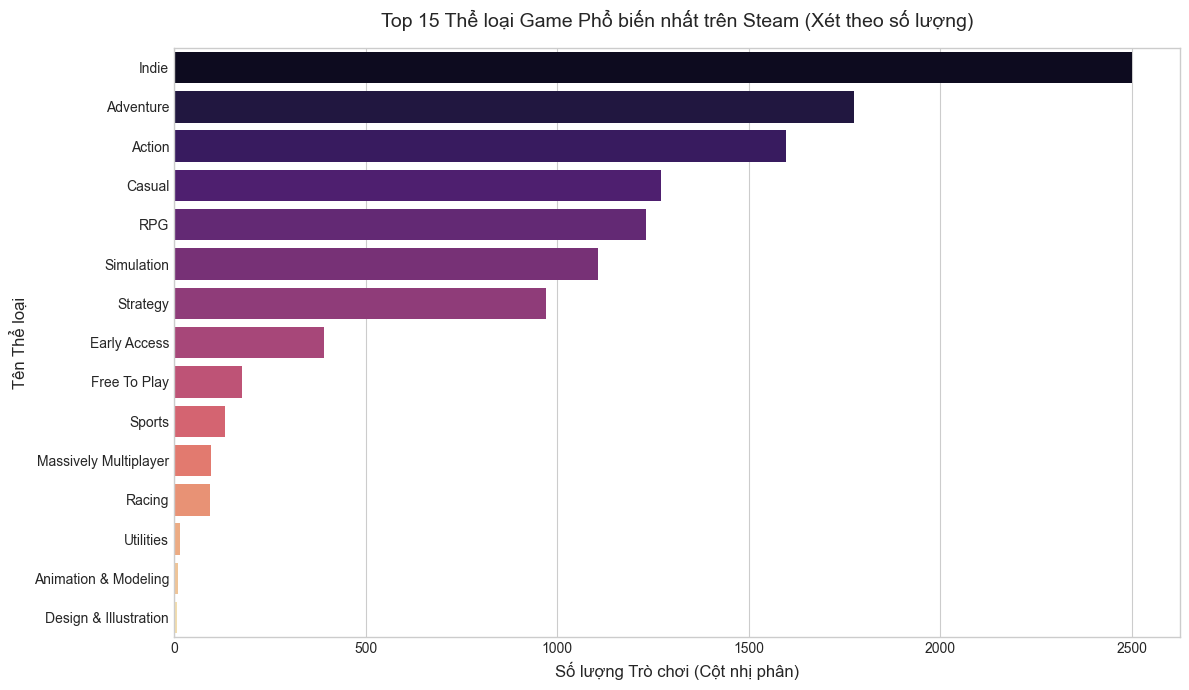

In [25]:
# Tính toán tổng số lượng game thuộc mỗi thể loại
genre_counts = df[genre_cols].sum().sort_values(ascending=False).head(15)
genre_names = [name.replace('genre_', '') for name in genre_counts.index]

plt.figure(figsize=(12, 7))
sns.barplot(x=genre_counts.values, y=genre_names, palette='magma')
plt.title('Top 15 Thể loại Game Phổ biến nhất trên Steam (Xét theo số lượng)', pad=15)
plt.xlabel('Số lượng Trò chơi (Cột nhị phân)')
plt.ylabel('Tên Thể loại')
plt.tight_layout()
plt.show()

### Trực quan hóa Top 10 Thể loại theo Đánh giá Trọng số

C:\Users\Tuyen\AppData\Local\Temp\ipykernel_30688\3590173679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weighted Rating', y='Genre', data=genre_perf_df.head(10), palette='viridis')


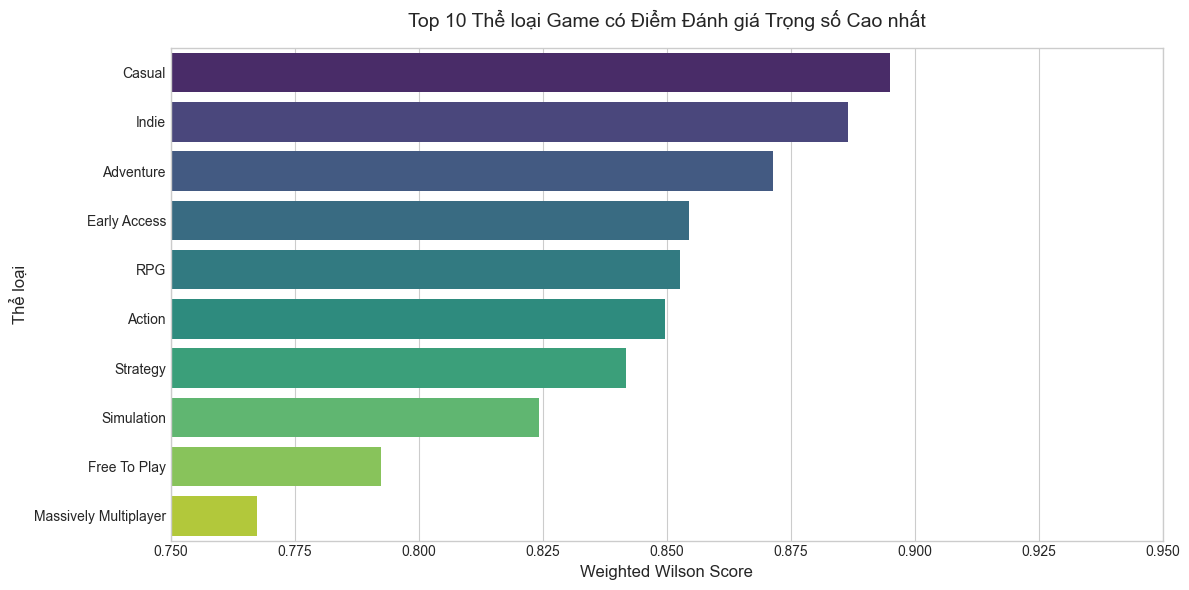

In [26]:
genre_performance = []
for genre_col in genre_cols:
    genre_name = genre_col.replace('genre_', '')
    genre_mask = df[genre_col] == 1
    genre_df = df[genre_mask]
    if len(genre_df) >= 50:
        weighted_rating = (genre_df['wilson_score'] * genre_df['total_ratings']).sum() / genre_df['total_ratings'].sum()
        genre_performance.append({'Genre': genre_name, 'Games': len(genre_df), 'Weighted Rating': weighted_rating})

genre_perf_df = pd.DataFrame(genre_performance).sort_values('Weighted Rating', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Weighted Rating', y='Genre', data=genre_perf_df.head(10), palette='viridis')
plt.title('Top 10 Thể loại Game có Điểm Đánh giá Trọng số Cao nhất', pad=15)
plt.xlabel('Weighted Wilson Score')
plt.ylabel('Thể loại')
plt.xlim(0.75, 0.95)
plt.tight_layout()
plt.show()

### Trực quan hóa Phân biệt Rating theo Phân khúc Giá bằng Boxplot

C:\Users\Tuyen\AppData\Local\Temp\ipykernel_30688\2809298862.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_group', y='wilson_score', data=df, order=price_order, palette='Set2')


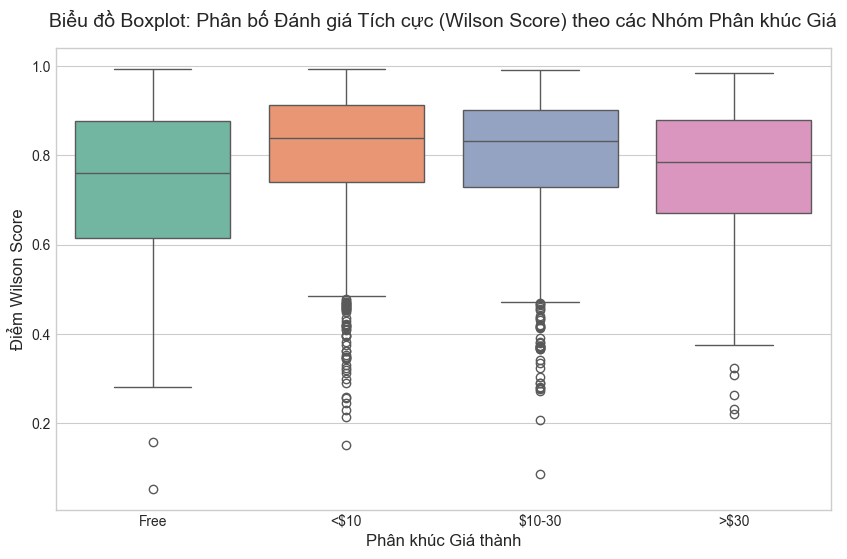

In [27]:
plt.figure(figsize=(10, 6))
price_order = ['Free', '<$10', '$10-30', '>$30']

sns.boxplot(x='price_group', y='wilson_score', data=df, order=price_order, palette='Set2')
plt.title('Biểu đồ Boxplot: Phân bố Đánh giá Tích cực (Wilson Score) theo các Nhóm Phân khúc Giá', pad=15)
plt.xlabel('Phân khúc Giá thành')
plt.ylabel('Điểm Wilson Score')
plt.show()

## 2. Kiểm định Giả định Thống kê Tiền đề (Assumption Checking)
Trước khi tiến hành các phân tích thống kê suy luận tham số, việc thực hiện kiểm định giả định phân phối chuẩn và kiểm tra hiện tượng đa cộng tuyến giữa các đặc trưng định lượng độc lập là bắt buộc để đảm bảo tính hợp lệ về mặt khoa học.

In [28]:
print('=' * 60)
print('SHAPIRO-WILK TEST FOR NORMALITY')
print('=' * 60)

# Kiểm tra phân phối điểm Wilson Score
stat_r, p_r = stats.shapiro(df['wilson_score'].dropna())
print(f"Wilson Score -> W-Statistic: {stat_r:.4f}, p-value: {p_r:.4e}")
print(f"Kết luận: Biến mục tiêu 'wilson_score' {'KHÔNG tuân theo phân phối chuẩn' if p_r < 0.05 else 'tuân theo phân phối chuẩn'}")

# Kiểm tra phân phối biến giá liên tục
stat_p, p_p = stats.shapiro(df['price'].dropna())
print(f"Price        -> W-Statistic: {stat_p:.4f}, p-value: {p_p:.4e}")
print(f"Kết luận: Biến liên tục 'price' {'KHÔNG tuân theo phân phối chuẩn' if p_p < 0.05 else 'tuân theo phân phối chuẩn'}")

print("\n💡 BIỆN LUẬN LÝ THUYẾT NỀN TẢNG:")
print("Hệ thống kiểm định Shapiro-Wilk rất nhạy bén với các sai lệch biên khi cỡ mẫu lớn (N > 3000).")
print("Tuy nhiên, áp dụng Định lý Giới hạn Trung tâm (Central Limit Theorem - CLT), do kích thước mẫu dữ liệu")
print("vượt xa ngưỡng an toàn tiêu chuẩn N > 30, phân phối của trị trung bình mẫu sẽ xấp xỉ phân phối chuẩn.")
print("Do đó, các phép kiểm định tham số như T-test và ANOVA vẫn đảm bảo tính vững vững chắc và hợp lệ.")

SHAPIRO-WILK TEST FOR NORMALITY
Wilson Score -> W-Statistic: 0.9154, p-value: 4.0927e-42
Kết luận: Biến mục tiêu 'wilson_score' KHÔNG tuân theo phân phối chuẩn
Price        -> W-Statistic: 0.8471, p-value: 9.9205e-52
Kết luận: Biến liên tục 'price' KHÔNG tuân theo phân phối chuẩn

💡 BIỆN LUẬN LÝ THUYẾT NỀN TẢNG:
Hệ thống kiểm định Shapiro-Wilk rất nhạy bén với các sai lệch biên khi cỡ mẫu lớn (N > 3000).
Tuy nhiên, áp dụng Định lý Giới hạn Trung tâm (Central Limit Theorem - CLT), do kích thước mẫu dữ liệu
vượt xa ngưỡng an toàn tiêu chuẩn N > 30, phân phối của trị trung bình mẫu sẽ xấp xỉ phân phối chuẩn.
Do đó, các phép kiểm định tham số như T-test và ANOVA vẫn đảm bảo tính vững vững chắc và hợp lệ.


In [29]:
print('=' * 60)
print('VARIANCE INFLATION FACTOR (VIF) ANALYSIS')
print('=' * 60)

# Loại bỏ positive_ratings và negative_ratings để tránh đa cộng tuyến hoàn hảo với total_ratings (total = pos + neg)
numerical_features = ['price', 'total_ratings', 'discount', 'year']
X_vif = df[numerical_features].dropna()
X_vif = sm.add_constant(X_vif) # Thêm hằng số Intercept bắt buộc cho mô hình VIF

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Chỉ in kết quả các đặc trưng loại trừ hằng số mẫu
result_vif = vif_data[vif_data["Feature"] != "const"].sort_values("VIF_Score", ascending=False)
print(result_vif.to_string(index=False))

print("\n📋 HƯỚNG DẪN ĐỌC CHỈ SỐ VIF:")
print("- VIF < 5: Đặc trưng độc lập tốt, không tồn tại hiện tượng đa cộng tuyến đáng kể.")
print("- VIF từ 5 - 10: Có dấu hiệu cộng tuyến nhẹ, cần theo dõi thêm cấu trúc.")
print("- VIF > 10: Đa cộng tuyến nghiêm trọng, bắt buộc phải loại bỏ hoặc kết hợp biến.")

VARIANCE INFLATION FACTOR (VIF) ANALYSIS
      Feature  VIF_Score
        price   1.043787
total_ratings   1.033303
     discount   1.007428
         year   1.004000

📋 HƯỚNG DẪN ĐỌC CHỈ SỐ VIF:
- VIF < 5: Đặc trưng độc lập tốt, không tồn tại hiện tượng đa cộng tuyến đáng kể.
- VIF từ 5 - 10: Có dấu hiệu cộng tuyến nhẹ, cần theo dõi thêm cấu trúc.
- VIF > 10: Đa cộng tuyến nghiêm trọng, bắt buộc phải loại bỏ hoặc kết hợp biến.


## 3. Thống kê Suy luận & Kiểm định Giả thuyết
### 3.1. So sánh Trị trung bình giữa hai Nhóm Độc lập (Game Free vs Paid)
- **Giả thuyết $H_0$:** Không có sự khác biệt về tỉ lệ đánh giá tích cực trung bình giữa game miễn phí và có phí.
- **Giả thuyết $H_1$:** Có sự khác biệt rõ rệt về tỉ lệ đánh giá tích cực giữa hai mô hình doanh thu này.
- **Giải pháp áp dụng:** Sử dụng phép kiểm định **Welch's T-test** nhằm kiểm soát trường hợp cỡ mẫu mất cân bằng lớn và phương sai hai nhóm không đồng nhất.

C:\Users\Tuyen\AppData\Local\Temp\ipykernel_30688\2624870697.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_free', y='wilson_score', data=df, inner="quartile", palette=['#4C72B0', '#C44E52'])


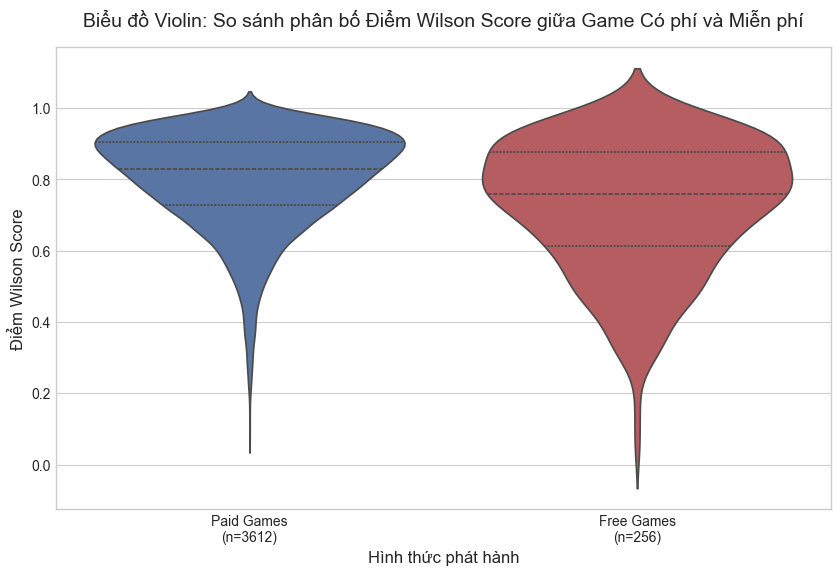

WELCH'S T-TEST EXTENDED REPORT
Trị trung bình nhóm Free: 0.7265
Trị trung bình nhóm Paid: 0.8018
T-statistic value:       -6.5433
P-value đạt được:        2.9174e-10
95% Khoảng Tin Cậy (CI): [-0.0980, -0.0527]
Hệ số Cỡ Hiệu ứng d:     -0.5412
--> Nhận định ý nghĩa thực tiễn: Mức độ tác động thực tế ở dạng 'Trung bình (Medium)'


In [30]:
def calculate_ci(data1, data2, alpha=0.05):
    """Tính Khoảng tin cậy (CI) cho hiệu hai trị trung bình độc lập áp dụng Welch's SE."""
    n1, n2 = len(data1), len(data2)
    var1, var2 = np.var(data1, ddof=1), np.var(data2, ddof=1)
    se = np.sqrt(var1/n1 + var2/n2)
    df_welch = ((var1/n1 + var2/n2)**2) / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))
    t_crit = stats.t.ppf(1 - alpha/2, df_welch)
    margin_of_error = t_crit * se
    diff = np.mean(data1) - np.mean(data2)
    return diff - margin_of_error, diff + margin_of_error

def calculate_cohens_d(data1, data2):
    """Tính cỡ hiệu ứng Cohen's d để đo lường mức độ ảnh hưởng thực tế ngoài chỉ số p-value."""
    n1, n2 = len(data1), len(data2)
    var1, var2 = np.var(data1, ddof=1), np.var(data2, ddof=1)
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    return (np.mean(data1) - np.mean(data2)) / np.sqrt(pooled_var)

# Trích xuất dữ liệu mảng sạch
free_ratings = df[df['is_free'] == 1]['wilson_score'].dropna()
paid_ratings = df[df['is_free'] == 0]['wilson_score'].dropna()

# Chạy kiểm định thống kê suy luận
t_stat, p_val_t = stats.ttest_ind(free_ratings, paid_ratings, equal_var=False)
ci_lower, ci_upper = calculate_ci(free_ratings, paid_ratings)
cohens_d = calculate_cohens_d(free_ratings, paid_ratings)

# Xuất biểu đồ Violin trực quan hóa phân phối tứ phân vị inline
plt.figure(figsize=(10, 6))
sns.violinplot(x='is_free', y='wilson_score', data=df, inner="quartile", palette=['#4C72B0', '#C44E52'])
plt.title('Biểu đồ Violin: So sánh phân bố Điểm Wilson Score giữa Game Có phí và Miễn phí', pad=15)
plt.xlabel('Hình thức phát hành')
plt.ylabel('Điểm Wilson Score')
plt.xticks([0, 1], [f'Paid Games\n(n={len(paid_ratings)})', f'Free Games\n(n={len(free_ratings)})'])
plt.show()

print('=' * 60)
print('WELCH\'S T-TEST EXTENDED REPORT')
print('=' * 60)
print(f"Trị trung bình nhóm Free: {free_ratings.mean():.4f}")
print(f"Trị trung bình nhóm Paid: {paid_ratings.mean():.4f}")
print(f"T-statistic value:       {t_stat:.4f}")
print(f"P-value đạt được:        {p_val_t:.4e}")
print(f"95% Khoảng Tin Cậy (CI): [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Hệ số Cỡ Hiệu ứng d:     {cohens_d:.4f}")

if abs(cohens_d) < 0.2: eff_str = "Không đáng kể"
elif abs(cohens_d) < 0.5: eff_str = "Nhỏ (Small)"
elif abs(cohens_d) < 0.8: eff_str = "Trung bình (Medium)"
else: eff_str = "Lớn (Large)"
print(f"--> Nhận định ý nghĩa thực tiễn: Mức độ tác động thực tế ở dạng '{eff_str}'")

### 3.2. So sánh Đa nhóm theo Phân khúc Giá thành (One-Way ANOVA & Tukey HSD)
Nhằm mở rộng việc phân tích hành vi người dùng theo phân khúc giá (biến categorical `price_group`), ta thực hiện kiểm định ANOVA một hướng để đánh giá tính đồng nhất giữa các nhóm giá, kèm theo hậu kiểm Tukey HSD để bóc tách từng cặp quan hệ khác biệt.

ONE-WAY ANOVA: WILSON SCORE BY PRICE GROUP
ANOVA F-statistic score: 34.1857, p-value: 8.4417e-22

👉 KẾT LUẬN: Bác bỏ H0. Có sự khác biệt mang ý nghĩa thống kê về điểm số giữa các nhóm giá.

--- THỰC THI KIỂM ĐỊNH SAU HẬU NGHIỆM (TUKEY HSD POST-HOC) ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
$10-30   <$10   0.0054 0.6857 -0.0071  0.0179  False
$10-30   >$30  -0.0399    0.0 -0.0605 -0.0193   True
$10-30   Free   -0.077    0.0  -0.101 -0.0531   True
  <$10   >$30  -0.0453    0.0  -0.066 -0.0245   True
  <$10   Free  -0.0824    0.0 -0.1065 -0.0584   True
  >$30   Free  -0.0372 0.0056 -0.0662 -0.0081   True
----------------------------------------------------


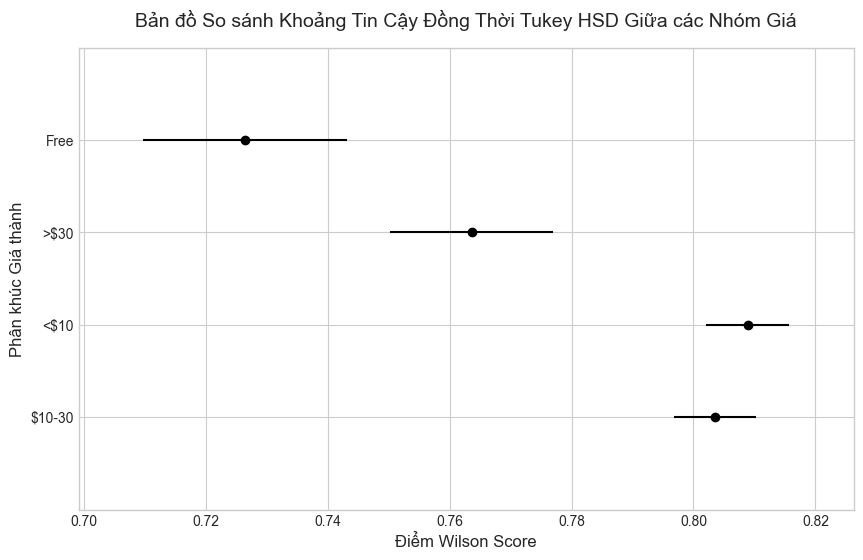

In [31]:
print('=' * 60)
print('ONE-WAY ANOVA: WILSON SCORE BY PRICE GROUP')
print('=' * 60)

# Gom cụm dữ liệu phân lớp
unique_groups = df['price_group'].dropna().unique()
anova_inputs = [df[df['price_group'] == g]['wilson_score'].dropna() for g in unique_groups]

f_stat, p_val_anova = stats.f_oneway(*anova_inputs)
print(f"ANOVA F-statistic score: {f_stat:.4f}, p-value: {p_val_anova:.4e}")

if p_val_anova < 0.05:
    print("\n👉 KẾT LUẬN: Bác bỏ H0. Có sự khác biệt mang ý nghĩa thống kê về điểm số giữa các nhóm giá.")
    print("\n--- THỰC THI KIỂM ĐỊNH SAU HẬU NGHIỆM (TUKEY HSD POST-HOC) ---")
    
    # Thực hiện so sánh cặp đồng thời bảo toàn alpha tổng thể
    tukey_results = pairwise_tukeyhsd(endog=df['wilson_score'], groups=df['price_group'], alpha=0.05)
    print(tukey_results)
    
    # Trực quan hóa khoảng tin cậy đồng thời lồng ghép trực tiếp vào output
    fig = tukey_results.plot_simultaneous(xlabel='Điểm Wilson Score', ylabel='Phân khúc Giá thành', figsize=(10, 6))
    plt.title('Bản đồ So sánh Khoảng Tin Cậy Đồng Thời Tukey HSD Giữa các Nhóm Giá', pad=15)
    plt.show()
else:
    print("\n👉 KẾT LUẬN: Giữ lại H0. Điểm đánh giá tích cực giữa các phân khúc giá có sự tương đồng.")

### 3.3. Phân tích Tương quan Tuyến tính (Pearson Correlation) cho các Biến Liên tục
Đo lường mức độ liên kết tuyến tính giữa các trường số liên tục gồm: Giá tiền (`price`) tác động lên điểm đánh giá, và Quy mô thảo luận (Tổng lượt review `total_ratings`) tác động lên điểm đánh giá.

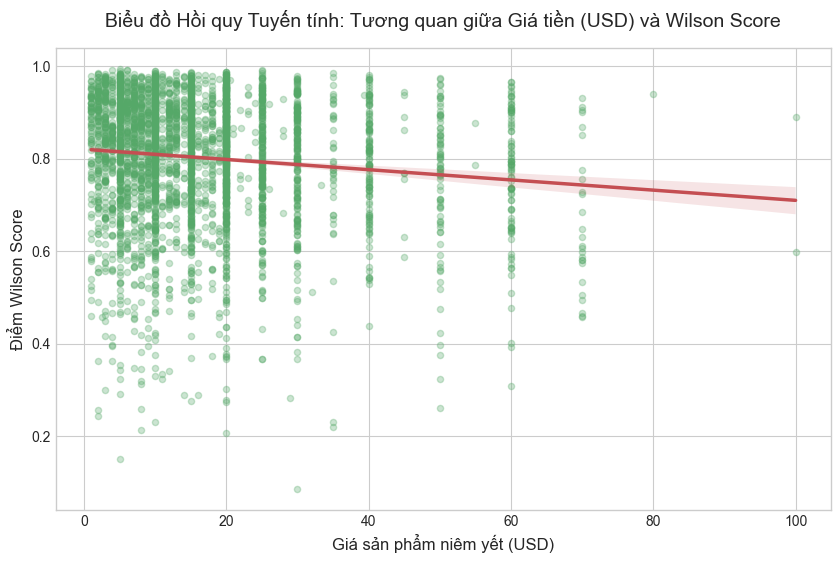

PEARSON CORRELATION METRICS ANALYSIS
1. Tương quan liên hệ giữa Giá tiền và Wilson Score:
   - Hệ số tương quan Pearson r: -0.1116
   - Chỉ số P-value tương ứng:   1.7745e-11
   - Ý nghĩa thống kê (alpha=0.05): CÓ Ý NGHĨA THỐNG KÊ

2. Tương quan liên hệ giữa Tổng số lượt Đánh giá và Wilson Score:
   - Hệ số tương quan Pearson r: 0.0470
   - Chỉ số P-value tương ứng:   4.7301e-03
   - Ý nghĩa thống kê (alpha=0.05): CÓ Ý NGHĨA THỐNG KÊ


In [32]:
# Chỉ phân tích tương quan giá trên nhóm game có phí để tránh tập trung giá trị 0 của game free làm sai lệch mô hình
paid_games_subset = df[df['is_free'] == 0].dropna(subset=['price', 'wilson_score', 'total_ratings'])

plt.figure(figsize=(10, 6))

# Đặt alpha=0.3 giúp tạo độ trong suốt điểm dữ liệu, tối ưu hóa hiển thị mật độ tập trung và tránh tràn bộ nhớ đệm
sns.regplot(x='price', y='wilson_score', data=paid_games_subset, 
            scatter_kws={'alpha':0.3, 's':20, 'color': '#55A868'}, 
            line_kws={'color':'#C44E52', 'linewidth': 2.5})

plt.title('Biểu đồ Hồi quy Tuyến tính: Tương quan giữa Giá tiền (USD) và Wilson Score', pad=15)
plt.xlabel('Giá sản phẩm niêm yết (USD)')
plt.ylabel('Điểm Wilson Score')
plt.show()

# Tính toán các chỉ số kiểm định Pearson
corr_price, p_price = stats.pearsonr(paid_games_subset['price'], paid_games_subset['wilson_score'])
corr_reviews, p_reviews = stats.pearsonr(paid_games_subset['total_ratings'], paid_games_subset['wilson_score'])

print('=' * 60)
print('PEARSON CORRELATION METRICS ANALYSIS')
print('=' * 60)
print(f"1. Tương quan liên hệ giữa Giá tiền và Wilson Score:")
print(f"   - Hệ số tương quan Pearson r: {corr_price:.4f}")
print(f"   - Chỉ số P-value tương ứng:   {p_price:.4e}")
print(f"   - Ý nghĩa thống kê (alpha=0.05): {'CÓ Ý NGHĨA THỐNG KÊ' if p_price < 0.05 else 'KHÔNG CÓ Ý NGHĨA THỐNG KÊ'}")

print(f"\n2. Tương quan liên hệ giữa Tổng số lượt Đánh giá và Wilson Score:")
print(f"   - Hệ số tương quan Pearson r: {corr_reviews:.4f}")
print(f"   - Chỉ số P-value tương ứng:   {p_reviews:.4e}")
print(f"   - Ý nghĩa thống kê (alpha=0.05): {'CÓ Ý NGHĨA THỐNG KÊ' if p_reviews < 0.05 else 'KHÔNG CÓ Ý NGHĨA THỐNG KÊ'}")